# EMIT atmospheric correction visualization

Inspect the supplied EMIT L1B_RAD granule and its hGRS L2A product: L1 top-of-atmosphere reflectance (`Rtoa`), corrected hGRS reflectance (`π × Rrs`), aerosol/glint and water-vapour retrievals, masks, and a matched pixel spectrum. The large L1 cube is read one selected band or pixel at a time.

The L1B radiance unit is `uW/cm²/sr/nm`; the notebook applies the same factor of 10 used by the reader to express it in `mW/m²/sr/nm`. Scene angles below are the supplied scene-constant observations. This is a diagnostic visualization, not independent validation of the retrieval or cloud mask.


In [10]:
from pathlib import Path
from datetime import datetime

import h5netcdf
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from hgrs import Misc, SolarIrradiance, SensorDescription
from hgrs.spectral_sensitivity import Gaussian

ROOT = Path.cwd().parent
EMIT_L1 = Path.home() / 'Documents/data/hyperspectral/EMIT/EMIT_L1B_RAD_001_20260823T090112_2623506_033.nc'
EMIT_L2A = ROOT / 'test_data/emit/EMIT_L1B_RAD_001_20260823T090112_2623506_033_L2A_hgrs_V1.1.2.nc'
SUN_AZIMUTH_DEG = 338.17
SUN_ELEVATION_DEG = 56.08  # 90 - supplied to-sun zenith (33.92 degrees)
VIEW_AZIMUTH_DEG = 141.32
VIEW_ZENITH_DEG = 10.08
RGB_WAVELENGTHS_NM = (665.0, 560.0, 490.0)
SPECTRUM_PIXEL = (240, 621)  # (row, column) on the current native-swath L2A grid
print('L1:', EMIT_L1, EMIT_L1.exists())
print('L2A:', EMIT_L2A, EMIT_L2A.exists())


L1: /nethome/lavardma/Documents/data/hyperspectral/EMIT/EMIT_L1B_RAD_001_20260823T090112_2623506_033.nc True
L2A: /home/lavardma/Documents/project/atmospheric/hgrs-refactor/test_data/emit/EMIT_L1B_RAD_001_20260823T090112_2623506_033_L2A_hgrs_V1.1.2.nc True


## Load hGRS L2A and EMIT spectral metadata

The L2A NetCDF remains lazy until selected bands or pixels are accessed. Spectral metadata and geolocation are small compared with the radiance cube.


In [11]:
if not EMIT_L1.is_file():
    raise FileNotFoundError(f'Edit EMIT_L1 to point to the EMIT L1B_RAD file: {EMIT_L1}')
if not EMIT_L2A.is_file():
    raise FileNotFoundError(f'Edit EMIT_L2A to point to the hGRS output: {EMIT_L2A}')
l2 = xr.open_dataset(EMIT_L2A)
print('L2A dimensions:', dict(l2.sizes))
print('L2A variables:', list(l2.data_vars))
print('Acquisition:', l2.attrs.get('acquisition_date'))

with h5netcdf.File(EMIT_L1, 'r') as src:
    rad = src.variables['radiance']
    l1_wavelengths = np.asarray(src.groups['sensor_band_parameters'].variables['wavelengths'][:], dtype=np.float64)
    l1_fwhm = np.asarray(src.groups['sensor_band_parameters'].variables['fwhm'][:], dtype=np.float64)
    l1_shape = rad.shape[:2]
    l1_fill = float(rad.attrs.get('_FillValue', -9999.0))
    print('L1 radiance shape (y, x, bands):', rad.shape)
    print('L1 wavelengths:', float(l1_wavelengths.min()), 'to', float(l1_wavelengths.max()), 'nm')


L2A dimensions: {'wl': 91, 'y': 1280, 'x': 1242, 'yc': 64, 'xc': 63}
L2A variables: ['Rrs', 'brdfg_full', 'lon', 'lat', 'tcwv', 'tcwv_std', 'water_vapor_validity_mask', 'tcwv_smooth', 'aot_ref', 'brdfg', 'aot_ref_std', 'brdfg_std', 'aerosol_retrieval_validity_mask', 'water_validity_mask', 'aerosol_validity_mask', 'aot_ref_smoothed', 'water_pix_prop', 'water_mask', 'cloud_mask', 'pressure', 'to3c', 'tno2c']
Acquisition: 2026-08-23T09:01:12+00:00
L1 radiance shape (y, x, bands): (1280, 1242, 285)
L1 wavelengths: 380.8578796386719 to 2492.776123046875 nm


## Convert selected L1 bands to `Rtoa`

This applies `π Ltoa / (F0 cos(SZA))` using the packaged TSIS spectrum, EMIT wavelength/FWHM response, Earth–Sun distance adjustment, and supplied solar elevation. Negative or fill radiance is masked. Only the three RGB bands are loaded for this map.


In [12]:
date = datetime.fromisoformat(l2.attrs['acquisition_date'])
solar = SolarIrradiance().tsis * Misc.earth_sun_correction(date.timetuple().tm_yday)
sensor = SensorDescription(name='EMIT', sensor_mod=Gaussian(l1_wavelengths, l1_fwhm))
f0 = sensor.convolve(solar, solar_irradiance=True)
mu0 = np.cos(np.radians(90.0 - SUN_ELEVATION_DEG))


def nearest_indices(wavelengths):
    return np.asarray([int(np.argmin(np.abs(l1_wavelengths - w))) for w in wavelengths])


def read_l1_rtoa_bands(band_indices):
    band_indices = np.asarray(band_indices, dtype=int)
    out = np.empty((*l1_shape, band_indices.size), dtype=np.float32)
    with h5netcdf.File(EMIT_L1, 'r') as src:
        rad = src.variables['radiance']
        for out_index, band_index in enumerate(band_indices):
            plane = np.asarray(rad[:, :, int(band_index)], dtype=np.float32)
            plane[plane == l1_fill] = np.nan
            plane[plane < 0] = np.nan
            out[:, :, out_index] = np.pi * (plane * 10.0) / (float(f0.values[int(band_index)]) * mu0)
    return out

rgb_indices = nearest_indices(RGB_WAVELENGTHS_NM)
l1_rtoa_rgb = read_l1_rtoa_bands(rgb_indices)
print('RGB band centers (nm):', l1_wavelengths[rgb_indices])


/home/lavardma/Documents/project/atmospheric/hgrs-refactor/hgrs/auxdata.py:96: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  solar_irr = xr.open_dataset(thuillier_file).squeeze().data.drop('time') * 1e3


RGB band centers (nm): [663.4934082  559.16644287 492.18521118]


## L1 versus hGRS L2A RGB

The L1 and L2A products use matching native-swath coordinates in this output. Both RGBs share one percentile stretch; hGRS `Rrs` is multiplied by π to express reflectance-like units. The visual match is a diagnostic and does not imply independent validation.


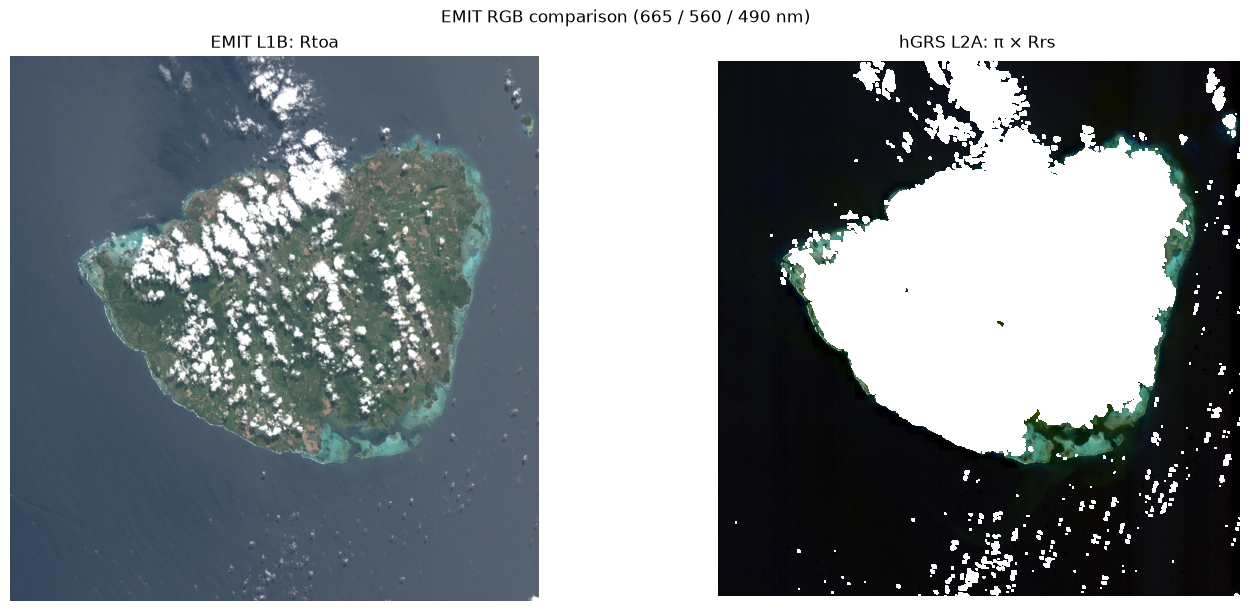

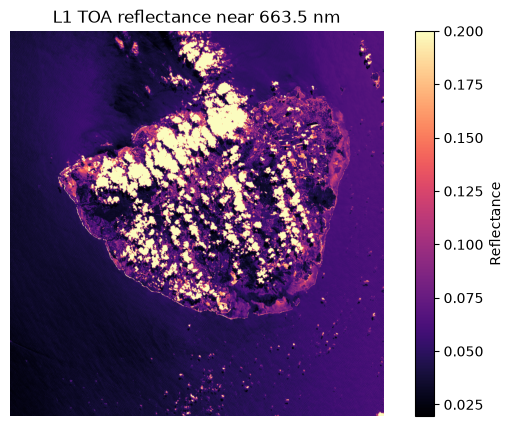

In [13]:
def stretch_rgb(rgb, limits=None):
    rgb = np.asarray(rgb, dtype=np.float32)
    if limits is None:
        limits = [(np.nanpercentile(rgb[..., c], 2), np.nanpercentile(rgb[..., c], 98)) for c in range(3)]
    view = np.empty_like(rgb)
    for c, (lo, hi) in enumerate(limits):
        view[..., c] = np.clip((rgb[..., c] - lo) / max(hi - lo, 1e-12), 0, 1) ** (1 / 1.8)
    return view, limits


def plot_rgb_pair(left, right, titles, title):
    both = np.concatenate((left.reshape(-1, 3), right.reshape(-1, 3)), axis=0)
    limits = [(np.nanpercentile(both[:, c], 2), np.nanpercentile(both[:, c], 98)) for c in range(3)]
    left_view, _ = stretch_rgb(left, limits)
    right_view, _ = stretch_rgb(right, limits)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
    for ax, image, label in zip(axes, (left_view, right_view), titles):
        ax.imshow(image, origin='upper')
        ax.set_title(label)
        ax.set_axis_off()
    fig.suptitle(title)
    plt.show()

l2_rgb = np.stack([
    np.asarray(l2.Rrs.sel(wl=float(w), method='nearest').values, dtype=np.float32) * np.pi
    for w in RGB_WAVELENGTHS_NM
], axis=-1)
plot_rgb_pair(l1_rtoa_rgb, l2_rgb,
               ('EMIT L1B: Rtoa', 'hGRS L2A: π × Rrs'),
               'EMIT RGB comparison (665 / 560 / 490 nm)')
plt.figure(figsize=(8, 5))
plt.imshow(l1_rtoa_rgb[..., 0], origin='upper', cmap='magma', vmax=0.2)
plt.title(f'L1 TOA reflectance near {l1_wavelengths[rgb_indices[0]]:.1f} nm')
plt.colorbar(label='Reflectance')
plt.axis('off')
plt.show()


## hGRS retrieval fields and masks

Display the full-resolution glint parameter when available, coarse aerosol/water-vapour retrievals, and the exported cloud/water masks.


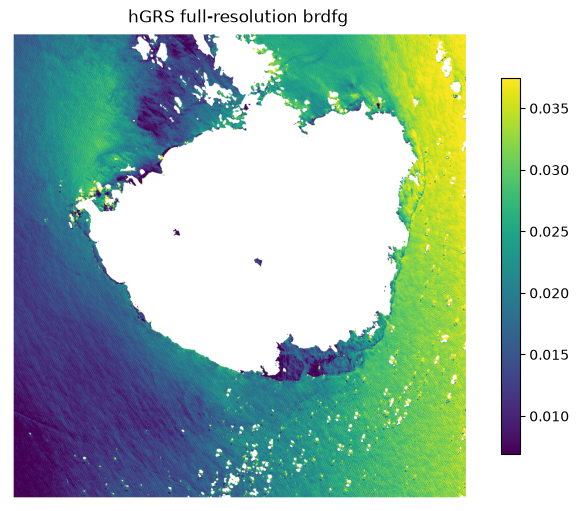

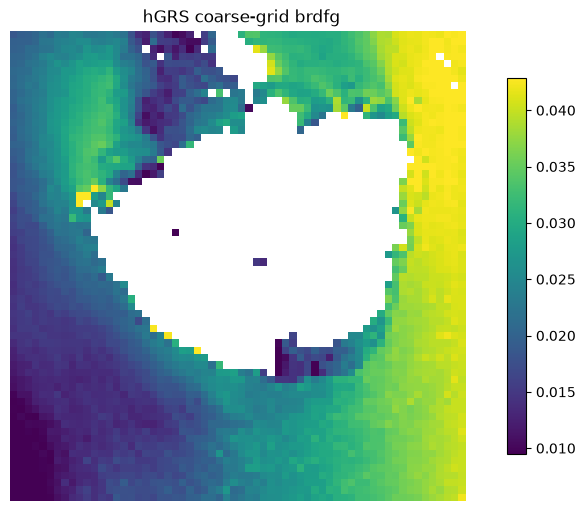

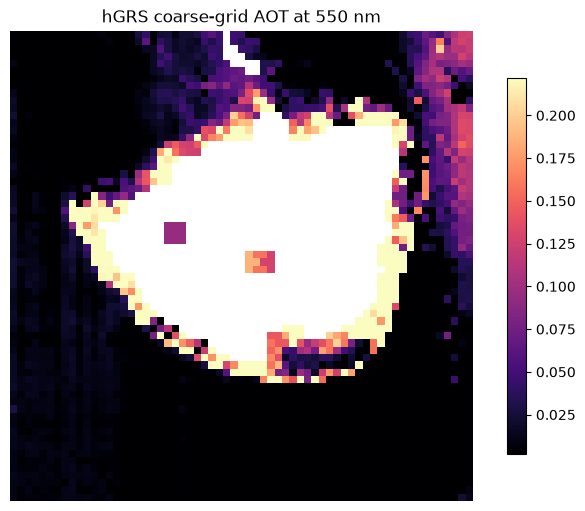

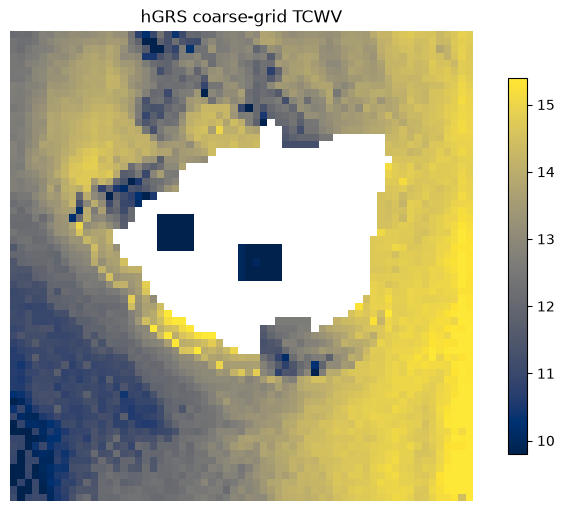

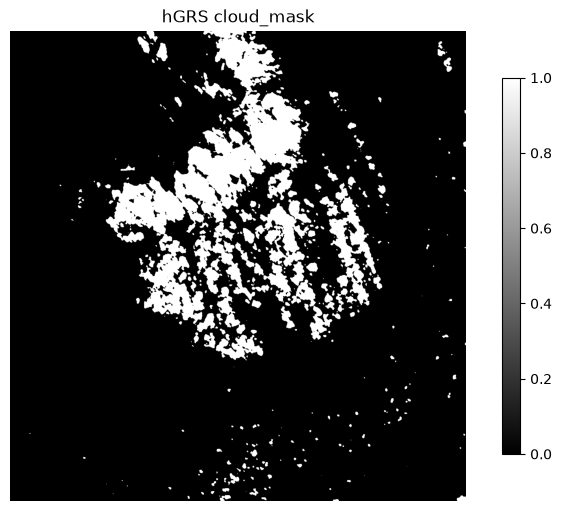

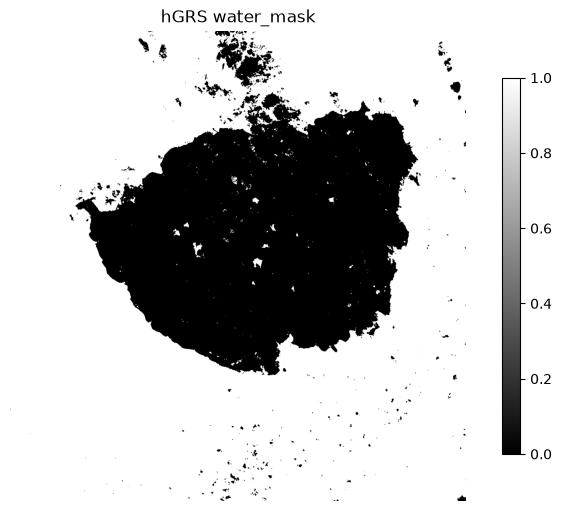

In [14]:
def show_map(da, title, cmap='viridis', percentiles=(2, 98)):
    values = np.asarray(da.values).squeeze()
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        print(f'{title}: no finite values')
        return
    lo, hi = np.percentile(finite, percentiles)
    fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
    im = ax.imshow(values, origin='upper', cmap=cmap, vmin=lo, vmax=hi)
    ax.set_title(title)
    ax.set_axis_off()
    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.show()

if 'brdfg_full' in l2:
    show_map(l2.brdfg_full, 'hGRS full-resolution brdfg')
if 'brdfg' in l2:
    show_map(l2.brdfg, 'hGRS coarse-grid brdfg')
if 'aot_ref' in l2:
    show_map(l2.aot_ref, 'hGRS coarse-grid AOT at 550 nm', cmap='magma')
if 'tcwv' in l2:
    show_map(l2.tcwv, 'hGRS coarse-grid TCWV', cmap='cividis')
for name in ('cloud_mask', 'water_mask'):
    if name in l2:
        show_map(l2[name], f'hGRS {name}', cmap='gray', percentiles=(0, 100))


## L1 `Rtoa` versus corrected spectrum at one pixel

Choose a pixel on the current native-swath output. L1 data are read for this pixel only; the plotted comparison uses π × hGRS `Rrs` to put both curves in reflectance units.


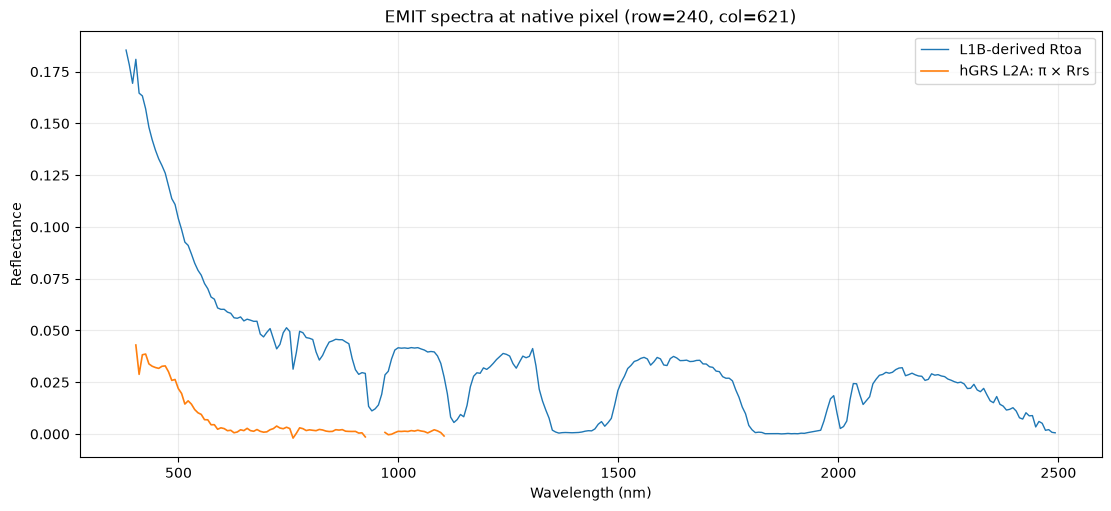

Pixel lon/lat: 57.41466758356771 -20.16593611168774


In [15]:
row, col = SPECTRUM_PIXEL
if not (0 <= row < l2.sizes['y'] and 0 <= col < l2.sizes['x']):
    raise IndexError(f'SPECTRUM_PIXEL {SPECTRUM_PIXEL} is outside L2A dimensions')
with h5netcdf.File(EMIT_L1, 'r') as src:
    l1_radiance_spectrum = np.asarray(src.variables['radiance'][row, col, :], dtype=np.float64)
l1_radiance_spectrum[l1_radiance_spectrum == l1_fill] = np.nan
l1_radiance_spectrum[l1_radiance_spectrum < 0] = np.nan
l1_rtoa_spectrum = np.pi * (l1_radiance_spectrum * 10.0) / (np.asarray(f0.values) * mu0)
l2_rrs_spectrum = np.asarray(l2.Rrs.isel(y=row, x=col).values, dtype=np.float64) * np.pi

fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
ax.plot(l1_wavelengths, l1_rtoa_spectrum, label='L1B-derived Rtoa', lw=1.0)
ax.plot(l2.wl.values, l2_rrs_spectrum, label='hGRS L2A: π × Rrs', lw=1.2)
ax.set(xlabel='Wavelength (nm)', ylabel='Reflectance',
       title=f'EMIT spectra at native pixel (row={row}, col={col})')
ax.grid(alpha=0.25)
ax.legend()
plt.show()
print('Pixel lon/lat:', float(l2.lon.isel(y=row, x=col)), float(l2.lat.isel(y=row, x=col)))


In [16]:
l2_rrs_spectrum

array([ 0.04297699,  0.0288084 ,  0.0382646 ,  0.03861017,  0.03386637,
        0.0327354 ,  0.03210708,  0.03169867,  0.03270398,  0.03289248,
        0.03006504,  0.02588672,  0.02632655,  0.02192832,  0.01957212,
        0.01445133,  0.01602212,  0.01441991,  0.01181239,  0.01024159,
        0.00945619,  0.0069115 ,  0.00684867,  0.00446106,  0.00449248,
        0.00229336,  0.00298451,  0.00260752,  0.00160221,  0.00179071,
        0.0005969 ,  0.00097389,  0.00204204,  0.00163363,  0.00273319,
        0.00163363,  0.00131947,  0.0021677 ,  0.00128805,  0.00087965,
        0.00103673,  0.00207345,  0.00260752,  0.00383274,  0.00289027,
        0.00254469,  0.00326726,  0.00263894, -0.0019792 ,  0.00034558,
        0.00298451,  0.00257611,  0.00166504,  0.00201062,  0.00179071,
        0.00160221,  0.00219911,  0.00194779,  0.00141372,  0.00119381,
        0.00125664,  0.00207345,  0.00188496,  0.00210487,  0.00135088,
        0.00125664,  0.00122522,  0.00125664,  0.00043982,  0.00

Close the lazy L2A dataset when finished.

In [17]:
l2.close()